In [1]:
import gymnasium as gym
from gymnasium import spaces
import numpy as np
import pandas as pd
import seaborn as sns
import torch
import matplotlib.pyplot as plt
import cvxpy as cp
from IPython.display import clear_output, display
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from matplotlib.patches import Rectangle, Circle, Polygon
import matplotlib.animation as animation
from io import BytesIO
import PIL.Image as Image
import imageio
import time
import networkx as nx

In [2]:
%load_ext autoreload
%reload_ext autoreload

from PowerSystemEnv import PowerSystemEnv, generate_system_network, build_matrices

System Network saved: .png and .pdf


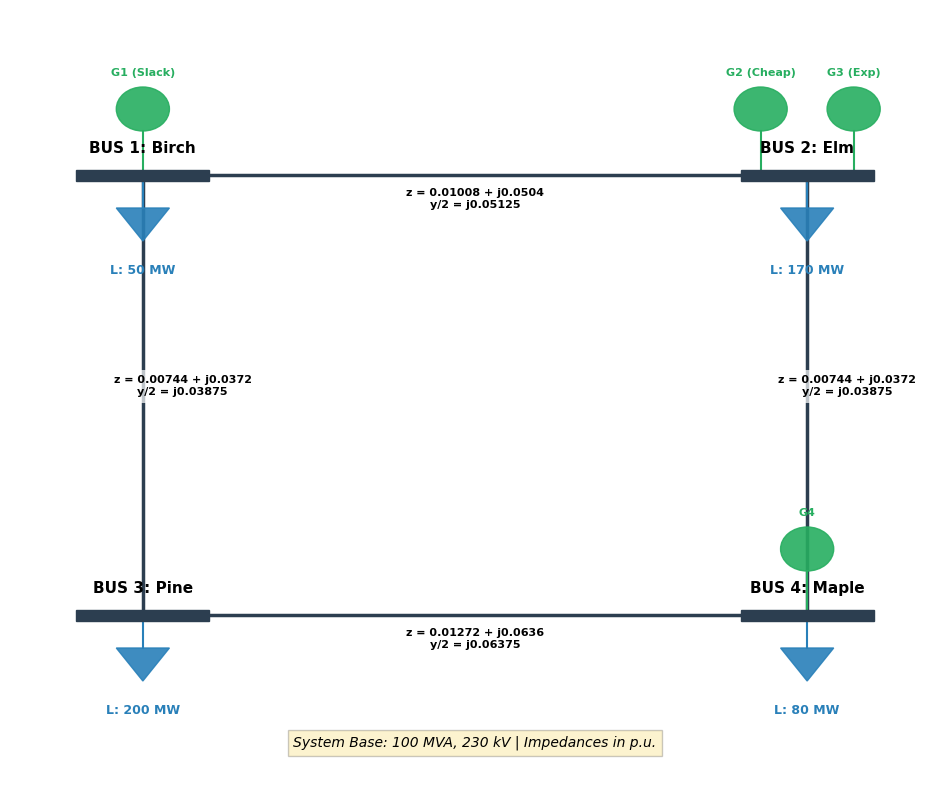

In [3]:
# 1. Generate the network configuration
network_data = generate_system_network()

In [4]:
# Build the physical matrices to test the PTDF
n_buses = 4
lines_data = [(0, 1, 0.0504), (0, 2, 0.0372), (1, 3, 0.0372), (2, 3, 0.0636)]
B_bus, PTDF, A = build_matrices(n_buses, lines_data)

print("PTDF Matrix Shape:", PTDF.shape)
print(PTDF)

PTDF Matrix Shape: (4, 4)
[[ 0.         -0.73248408 -0.19745223 -0.53503185]
 [ 0.         -0.26751592 -0.80254777 -0.46496815]
 [ 0.          0.26751592 -0.19745223 -0.53503185]
 [ 0.         -0.26751592  0.19745223 -0.46496815]]


C:\Users\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 129302 (\N{ROBOT FACE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


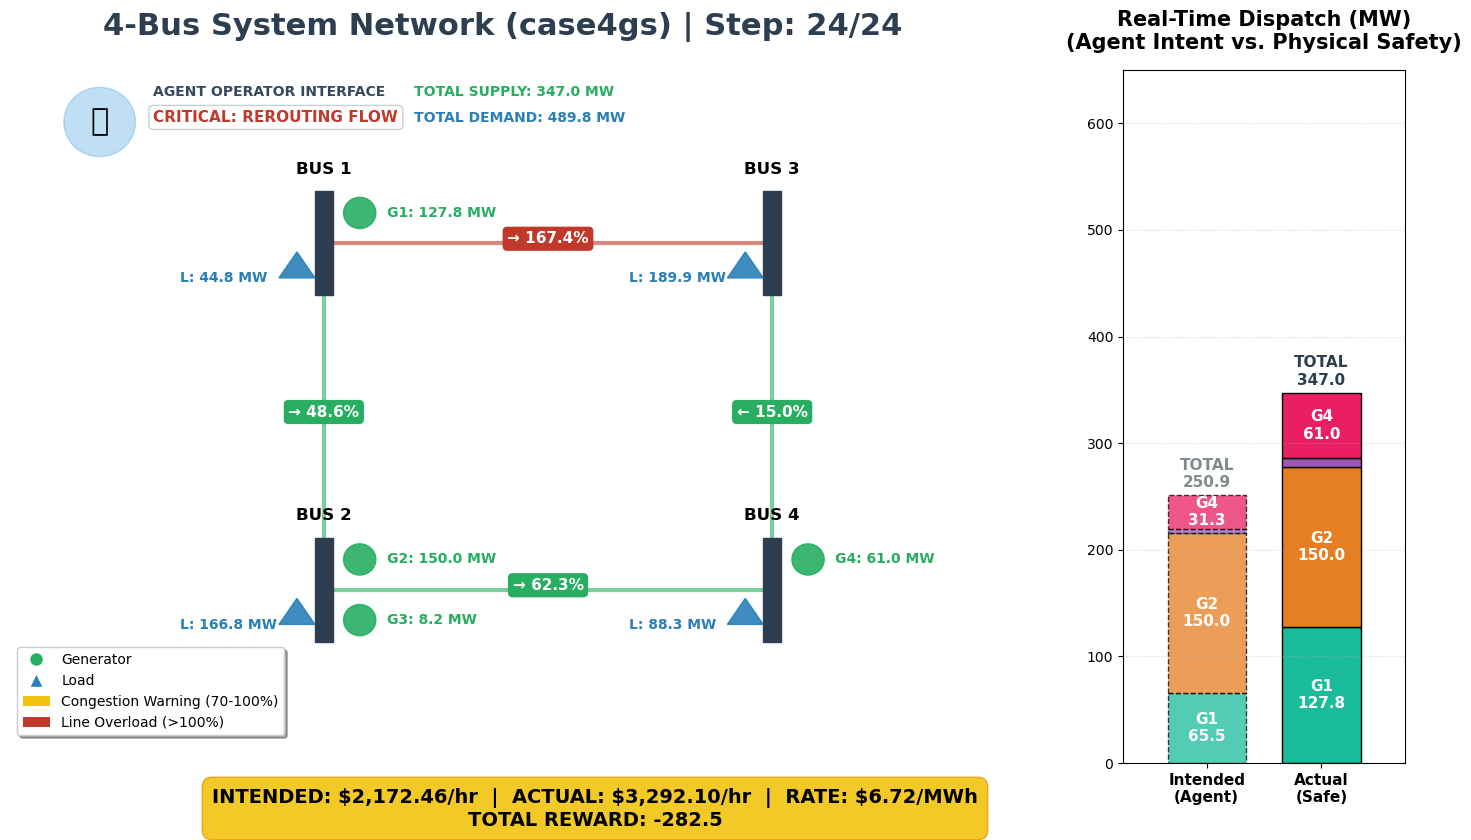

C:\Users\USER!\OneDrive - University at Buffalo\Morufdeen_Atilola_PhD_Journey\Classes\Spring26\CSE546\Assignment\Final Project\PowerSystemEnv.py:556: UserWarning: Glyph 129302 (\N{ROBOT FACE}) missing from font(s) DejaVu Sans.
  fig.savefig(buf, format='png', bbox_inches='tight', dpi=120, facecolor='white')



--- PERFORMANCE SUMMARY (UNTRAINED AGENT) ---
Total Steps: 24
Total Episode Reward: -282.55
Safety Intervention Rate: 100.00%
Avg. Violation Magnitude when Intervened: 74.1764 p.u. = 7417.64 MW
---------------------------------------------
Saving Gif...
Saving MP4...


IMAGEIO FFMPEG_WRITER WARNING: input image is not divisible by macro_block_size=16, resizing from (1766, 1007) to (1776, 1008) to ensure video compatibility with most codecs and players. To prevent resizing, make your input image divisible by the macro_block_size or set the macro_block_size to 1 (risking incompatibility).


In [5]:
env = PowerSystemEnv()
env.max_steps = 24
obs, info = env.reset()

total_reward = 0
intervention_count = 0  # Counter for when the Safety Layer had to act
total_raw_violation = 0

print(f"Running Untrained (Random) Agent Test for {env.max_steps} steps...")

# Test Loop
for step_idx in range(env.max_steps):
    action = env.action_space.sample() 
    
    obs, reward, terminated, truncated, info = env.step(action)
    total_reward += reward
    
    # We check 'raw_violation' which represents the agent's intent before the QP projection
    raw_v = info.get('raw_violation', 0)
    if raw_v > 0:
        intervention_count += 1
        total_raw_violation += raw_v
    
    env.render(mode="human", episode_reward=total_reward)

intervention_rate = (intervention_count / env.max_steps) * 100
avg_raw_violation = total_raw_violation / max(1, intervention_count)

print("\n--- PERFORMANCE SUMMARY (UNTRAINED AGENT) ---")
print(f"Total Steps: {env.max_steps}")
print(f"Total Episode Reward: {total_reward:.2f}")
print(f"Safety Intervention Rate: {intervention_rate:.2f}%")
print(f"Avg. Violation Magnitude when Intervened: {avg_raw_violation:.4f} p.u. = {(avg_raw_violation*100):.2f} MW")
print("---------------------------------------------")

print("Saving Gif...")
imageio.mimsave('Figures/untrained_agent_test.gif', env.frames, fps=2, loop=0)
print("Saving MP4...")
imageio.mimsave('Figures/untrained_agent_test.mp4', env.frames, fps=0.5, quality=9)

### Training Loop

C:\Users\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 129302 (\N{ROBOT FACE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


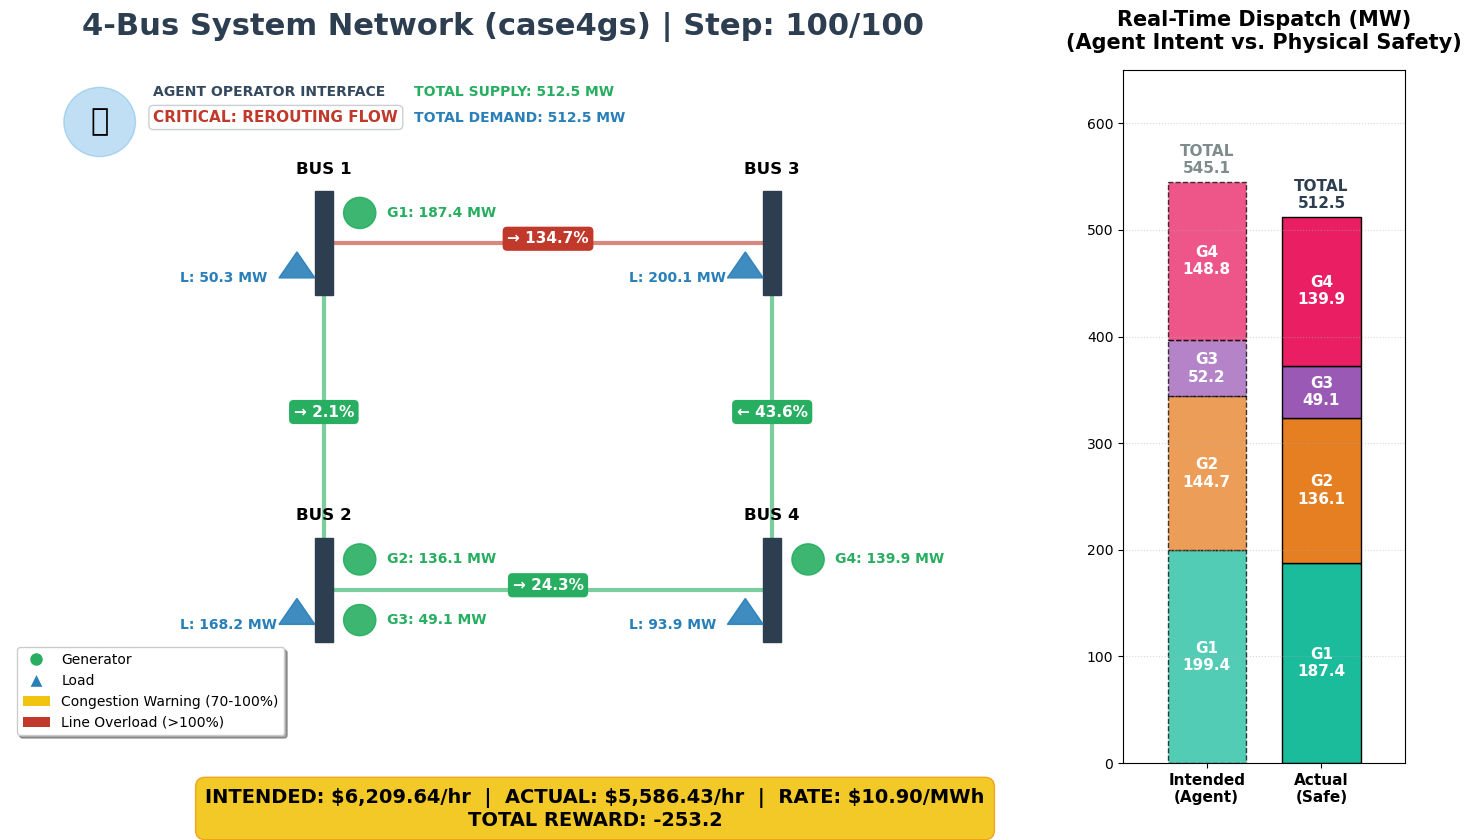

C:\Users\USER!\OneDrive - University at Buffalo\Morufdeen_Atilola_PhD_Journey\Classes\Spring26\CSE546\Assignment\Final Project\PowerSystemEnv.py:509: UserWarning: Glyph 129302 (\N{ROBOT FACE}) missing from font(s) DejaVu Sans.
  fig.savefig(buf, format='png', bbox_inches='tight', dpi=120, facecolor='white')


Ep: 3000 | Reward: -253.2 | Actual: $4985.68/hr

Success! Final model and training_csv saved.


In [6]:
from td3_model import TD3Agent, ReplayBuffer
from PowerSystemEnv import PowerSystemEnv

# --- Setup ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
env = PowerSystemEnv()
state_dim = env.observation_space.shape[0]
action_dim = env.action_space.shape[0]
max_action = float(env.action_space.high[0])

# Initialize agent
agent = TD3Agent(state_dim, action_dim, max_action)
replay_buffer = ReplayBuffer(state_dim, action_dim, device=device)

# --- Hyperparameters ---
max_timesteps = 300000 
start_timesteps = 2000 
batch_size = 256
expl_noise = 0.2 

history = {
    "total_step": [],
    "episode": [],
    "reward": [],
    "intended_cost": [],
    "actual_cost": [],
    "violation": [],
    "avg_loss_actor": [],
    "avg_loss_critic": []
}

state, _ = env.reset()
episode_reward, episode_cost, episode_violation = 0, 0, 0
episode_intended_cost_accum, episode_actual_cost_accum = 0, 0 
episode_timesteps, episode_num = 0, 0

actor_losses, critic_losses = [], []

# --- Training ---
for t in range(int(max_timesteps)):
    episode_timesteps += 1

    if t < start_timesteps:
        action = env.action_space.sample()
    else:
        action = (agent.select_action(state) + 
                  np.random.normal(0, max_action * expl_noise, size=action_dim)
                 ).clip(-max_action, max_action)

    next_state, reward, terminated, truncated, info = env.step(action)
    done = terminated or truncated
    replay_buffer.add(state, action, reward, next_state, done)

    state = next_state
    episode_reward += reward
    
    episode_cost += info['cost']
    episode_intended_cost_accum += info['intended_cost']
    episode_actual_cost_accum += info['actual_cost']
    episode_violation += info['raw_violation']

    if t >= start_timesteps:
        c_loss, a_loss = agent.train(replay_buffer, batch_size)
        critic_losses.append(c_loss)
        if a_loss is not None:
            actor_losses.append(a_loss)

    if done:
        avg_a_loss = np.mean(actor_losses) if actor_losses else 0
        avg_c_loss = np.mean(critic_losses) if critic_losses else 0
        
        # Calculate episode averages for the CSV
        avg_intended = episode_intended_cost_accum / episode_timesteps
        avg_actual = episode_actual_cost_accum / episode_timesteps
        
        history["total_step"].append(t + 1)
        history["episode"].append(episode_num + 1)
        history["reward"].append(episode_reward)
        history["violation"].append(episode_violation)
        history["avg_loss_actor"].append(avg_a_loss)
        history["avg_loss_critic"].append(avg_c_loss)
        history["intended_cost"].append(avg_intended)
        history["actual_cost"].append(avg_actual)

        if (episode_num + 1) % 50 == 0:
            # Passes current reward to render footer
            env.render(mode="human", episode_reward=episode_reward)
            print(f"Ep: {episode_num+1} | Reward: {episode_reward:.1f} | Actual: ${avg_actual:.2f}/hr")

        if (episode_num + 1) % 500 == 0:
            agent.save("td3_sced_latest_checkpoint.pth")

        # --- RESET BLOCK ---
        state, _ = env.reset()
        episode_reward, episode_cost, episode_violation = 0, 0, 0
        episode_intended_cost_accum, episode_actual_cost_accum = 0, 0 # RESET
        episode_timesteps = 0
        episode_num += 1
        actor_losses, critic_losses = [], []

# --- Save ---
agent.save("td3_sced_final_model.pth")
pd.DataFrame(history).to_csv("training_metrics.csv", index=False)
print("\nSuccess! Final model and training_csv saved.")

### Training Performance Analysis

In [7]:
def analyze_metric(data, column_name, label_name, color='#4C72B0', window=50, mastery_threshold=None):
    """
    Plots a specific metric with a light raw-data 'ghost' and a bold moving average.
    """
    values = data[column_name].values
    plt.style.use('seaborn-v0_8-darkgrid')
    plt.figure(figsize=(10, 6))

    # Plot Raw Data
    plt.plot(values, color=color, alpha=0.25, linewidth=1, label=f'Episode {label_name}')

    # Plot Moving Average
    if len(values) >= window:
        rolling_avg = pd.Series(values).rolling(window=window).mean()
        plt.plot(rolling_avg, color=color, linewidth=2.5, label=f'{window}-Ep Moving Avg')

    # Handle Mastery Vertical Line
    if mastery_threshold is not None and len(values) >= window:
        # Check against the rolling average for 'true' mastery
        mastery_idx = next((i for i, r in enumerate(rolling_avg) if r >= mastery_threshold), None)
        if mastery_idx:
            plt.axvline(mastery_idx, color='#DD8452', linestyle='--', linewidth=2, 
                        label=f'Mastery @ Ep {mastery_idx}')

    plt.title(f'Training Progress: {label_name}', fontsize=15, fontweight='black', pad=15)
    plt.xlabel('Episode', fontsize=12, fontweight='bold')
    plt.ylabel(label_name, fontsize=12, fontweight='bold')
    
    plt.legend(loc='best', frameon=True, facecolor='white', framealpha=0.9)
    
    plt.grid(True, which='both', linestyle='--', alpha=0.5)
    plt.tight_layout()

    filename = f"Figures/{column_name}_analysis.png"
    plt.savefig(filename, dpi=300, bbox_inches='tight')
    plt.savefig(filename.replace('.png', '.pdf'), bbox_inches='tight')
    
    print(f"Artifacts saved: {filename} (.png and .pdf)")
    plt.show()

In [8]:
df = pd.read_csv("training_metrics.csv")
df.head()

,total_step,episode,reward,intended_cost,actual_cost,violation,avg_loss_actor,avg_loss_critic
0,100,1,-986.957302,2646.726297,4543.227690,7550.168908,0.0,0.0
1,200,2,-856.113622,2578.947353,4435.925572,9213.469333,0.0,0.0
2,300,3,-1212.133461,2726.083879,4528.870889,6680.801053,0.0,0.0
3,400,4,-1057.693522,2746.025870,4395.076343,7247.120740,0.0,0.0
4,500,5,-891.179646,2774.644333,4717.465024,9449.052843,0.0,0.0


Artifacts saved: Figures/reward_analysis.png (.png and .pdf)


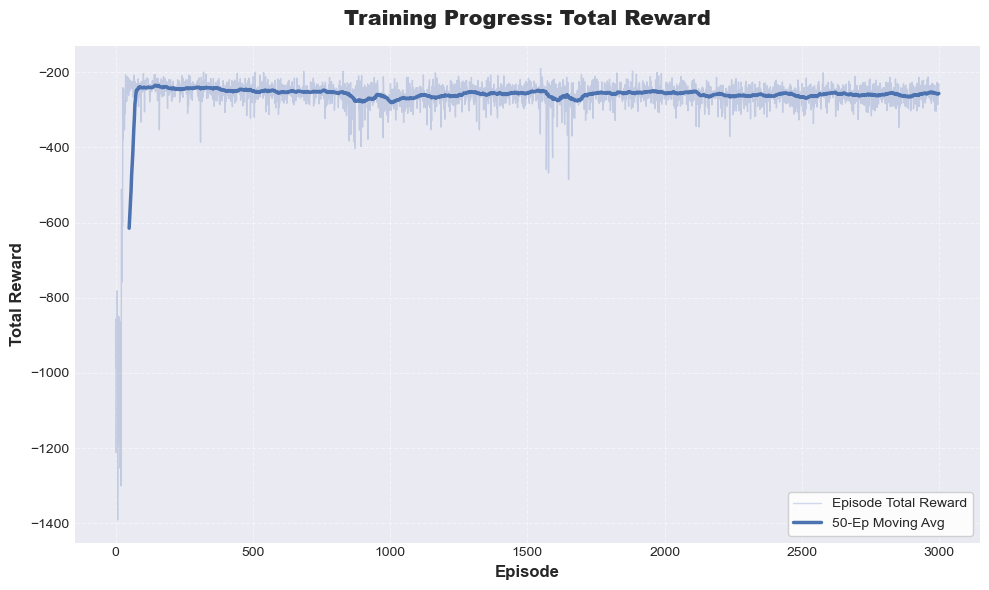

In [9]:
analyze_metric(df, 'reward', 'Total Reward', color='#4C72B0', mastery_threshold=-200)

Artifacts saved: Figures/avg_loss_critic_analysis.png (.png and .pdf)


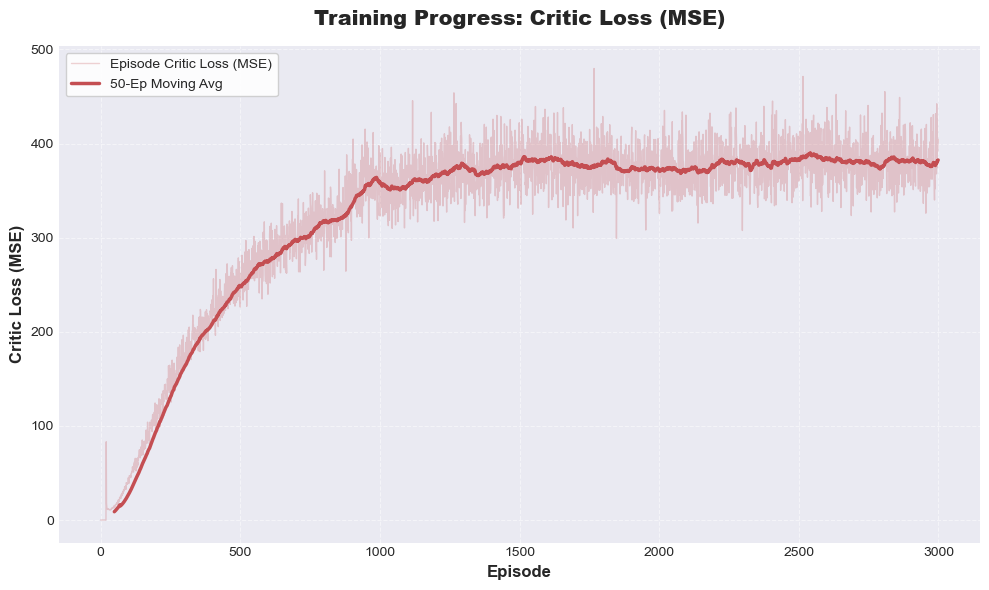

In [10]:
analyze_metric(df, 'avg_loss_critic', 'Critic Loss (MSE)', color='#C44E52')

Artifacts saved: Figures/avg_loss_actor_analysis.png (.png and .pdf)


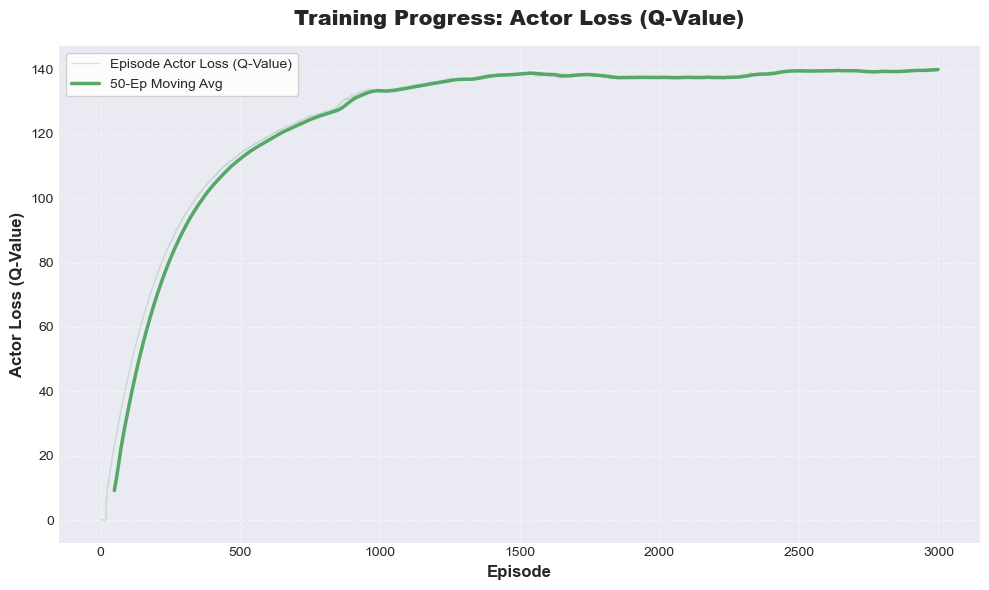

In [11]:
analyze_metric(df, 'avg_loss_actor', 'Actor Loss (Q-Value)', color='#55A868')

Artifacts saved: Figures/violation_analysis.png (.png and .pdf)


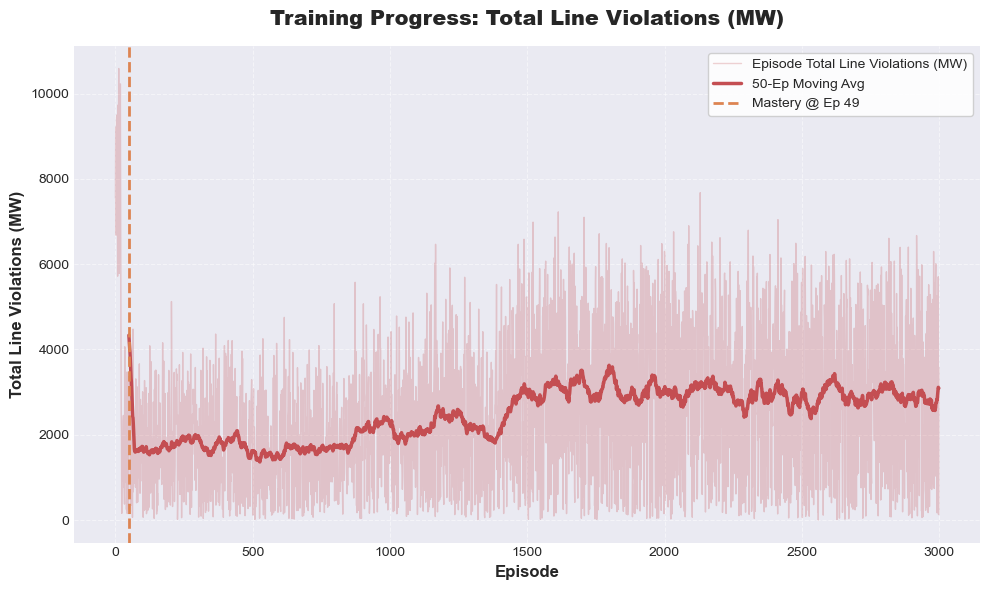

In [12]:
analyze_metric(df, 'violation', 'Total Line Violations (MW)', '#C44E52', mastery_threshold=0.5)

### Training Cost Comparison

Artifacts saved: Figures/cost_convergence_analysis.png (.png and .pdf)


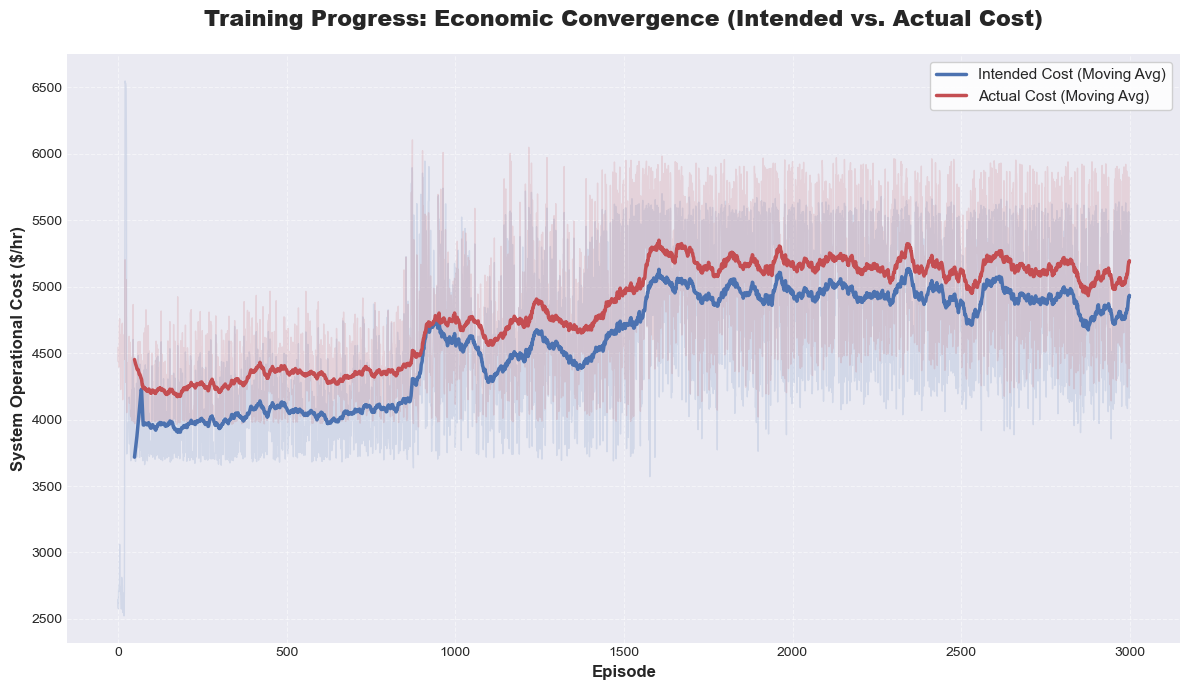

In [23]:
window = 50
plt.style.use('seaborn-v0_8-darkgrid')
plt.figure(figsize=(12, 7))

color_int = '#4C72B0' 
color_act = '#C44E52'

# Plot Raw Data
plt.plot(df['intended_cost'], color=color_int, alpha=0.15, linewidth=1)
plt.plot(df['actual_cost'], color=color_act, alpha=0.15, linewidth=1)

# Plot Moving Averages
if len(df) >= window:
    roll_int = df['intended_cost'].rolling(window=window).mean()
    roll_act = df['actual_cost'].rolling(window=window).mean()
    
    plt.plot(roll_int, color=color_int, linewidth=2.5, label='Intended Cost (Moving Avg)')
    plt.plot(roll_act, color=color_act, linewidth=2.5, label='Actual Cost (Moving Avg)')
    
plt.title('Training Progress: Economic Convergence (Intended vs. Actual Cost)', fontsize=16, fontweight='black', pad=20)
plt.xlabel('Episode', fontsize=12, fontweight='bold')
plt.ylabel('System Operational Cost ($/hr)', fontsize=12, fontweight='bold')

plt.legend(loc='upper right', frameon=True, facecolor='white', framealpha=0.9, fontsize=11)

plt.grid(True, which='both', linestyle='--', alpha=0.5)
plt.tight_layout()

filename = "Figures/cost_convergence_analysis.png"
plt.savefig(filename, dpi=300, bbox_inches='tight')
plt.savefig(filename.replace('.png', '.pdf'), bbox_inches='tight')

print(f"Artifacts saved: {filename} (.png and .pdf)")
plt.show()

### 24 TimeSteps Greedy Policy Evalauation

C:\Users\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 129302 (\N{ROBOT FACE}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


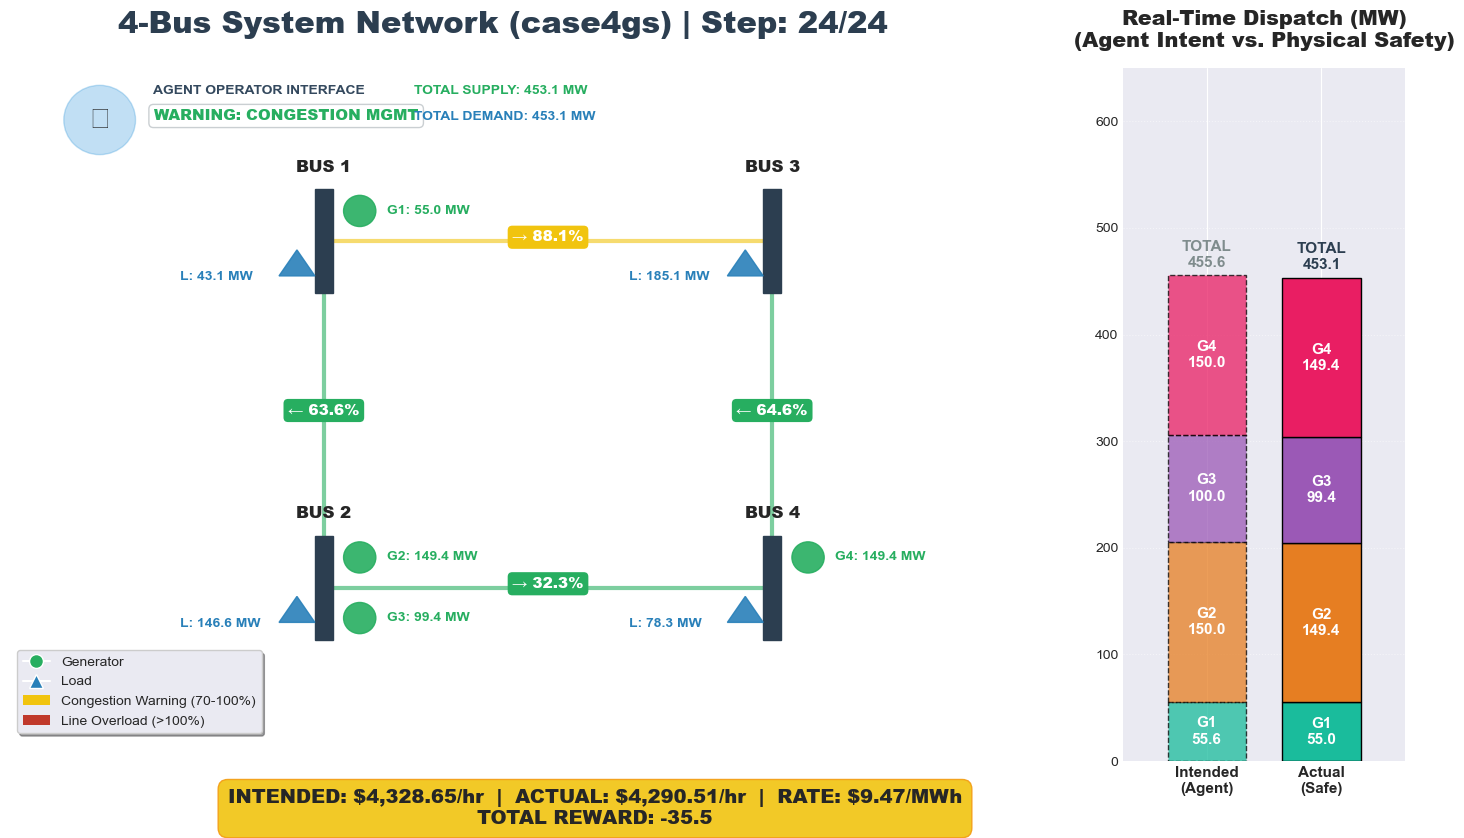

C:\Users\USER!\OneDrive - University at Buffalo\Morufdeen_Atilola_PhD_Journey\Classes\Spring26\CSE546\Assignment\Final Project\PowerSystemEnv.py:509: UserWarning: Glyph 129302 (\N{ROBOT FACE}) missing from font(s) Arial.
  fig.savefig(buf, format='png', bbox_inches='tight', dpi=120, facecolor='white')


Saving Gif...


IMAGEIO FFMPEG_WRITER WARNING: input image is not divisible by macro_block_size=16, resizing from (1757, 1005) to (1760, 1008) to ensure video compatibility with most codecs and players. To prevent resizing, make your input image divisible by the macro_block_size or set the macro_block_size to 1 (risking incompatibility).


Saving MP4...

--- 24-Hour Trial Summary ---
    step  intended_total_mw  actual_total_mw  intended_cost  actual_cost  \
19    20         445.244455       454.598195    4229.019979  4318.595731   
20    21         456.887996       453.619319    4341.970307  4292.682721   
21    22         454.508835       450.126167    4317.695065  4251.958939   
22    23         451.341271       451.505717    4286.328683  4287.930295   
23    24         455.589551       453.056346    4328.645781  4290.512151   

    raw_violation_mw  final_violation_mw  
19               0.0                 0.0  
20               0.0                 0.0  
21               0.0                 0.0  
22               0.0                 0.0  
23               0.0                 0.0  

Trial Finished. Total Reward: -36.61


In [13]:
from td3_model import TD3Agent
from PowerSystemEnv import PowerSystemEnv

# --- Setup and Load ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
env = PowerSystemEnv()
state_dim = env.observation_space.shape[0]
action_dim = env.action_space.shape[0]
max_action = float(env.action_space.high[0])
env.max_steps = 24

# Initialize and Load the weights
agent = TD3Agent(state_dim, action_dim, max_action)
agent.load("td3_sced_final_model.pth")
print("Model loaded successfully. Starting Greedy 24-Hour Trial...")

# --- 24-Step (Hour) Greedy Execution ---
state, _ = env.reset()
total_reward = 0
test_steps = 24  

test_history = {
    "step": [], 
    "intended_total_mw": [], 
    "actual_total_mw": [], 
    "intended_cost": [], 
    "actual_cost": [],
    "raw_violation_mw": [], 
    "final_violation_mw": []
}

for hour in range(test_steps):
    action = agent.select_action(state)
    next_state, reward, terminated, truncated, info = env.step(action)
    
    intended_mw = np.sum(env.intended_Pg) * 100
    actual_mw = np.sum(env.current_Pg) * 100
    
    test_history["step"].append(hour + 1)
    test_history["intended_total_mw"].append(intended_mw)
    test_history["actual_total_mw"].append(actual_mw)
    test_history["intended_cost"].append(info['intended_cost'])
    test_history["actual_cost"].append(info['actual_cost'])
    
    # CAPTURE THE VIOLATIONS
    test_history["raw_violation_mw"].append(info['raw_violation'])
    test_history["final_violation_mw"].append(info['violation'])
    
    env.render(mode="human", episode_reward=total_reward)
    
    state = next_state
    total_reward += reward

print("Saving Gif...")
imageio.mimsave('greedy_24hr_test.gif', env.frames, fps=2, loop=0)
print("Saving MP4...")
imageio.mimsave('greedy_24hr_test.mp4', env.frames, fps=0.5, quality=9)

# Convert to DataFrame for easy viewing
df_results = pd.DataFrame(test_history)
print("\n--- 24-Hour Trial Summary ---")
print(df_results.tail())
print(f"\nTrial Finished. Total Reward: {total_reward:.2f}")

df_results.to_csv("greedy_24hr_test.csv", index=False)

In [14]:
df_results

,step,intended_total_mw,actual_total_mw,intended_cost,actual_cost,raw_violation_mw,final_violation_mw
0,1,471.000642,463.089844,4498.591861,4376.776629,0.0,0.0
1,2,452.873963,463.087160,4301.370023,4408.107029,0.0,0.0
2,3,445.596349,461.420320,4232.218031,4389.914248,0.0,0.0
3,4,443.156934,463.079525,4210.324605,4408.023015,0.0,0.0
4,5,445.950514,463.834999,4235.450287,4416.367311,0.0,0.0
5,6,446.253413,465.069978,4238.225466,4430.141147,0.0,0.0
6,7,447.718138,463.871459,4251.785822,4416.771582,0.0,0.0
7,8,447.816002,462.685564,4252.700147,4403.696236,0.0,0.0
8,9,445.848197,462.292582,4234.514748,4399.396982,0.0,0.0
9,10,449.189091,461.691335,4265.638108,4392.851732,0.0,0.0


### Greedy Evalaution Plots

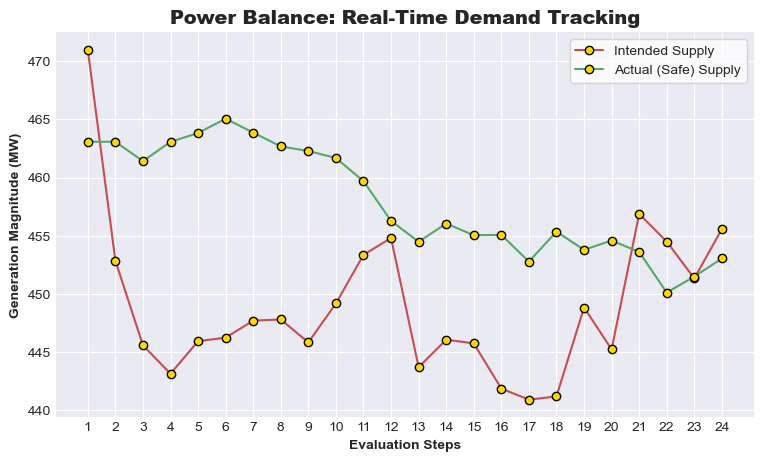

In [29]:
plt.style.use('seaborn-v0_8-darkgrid')
steps = df_results['step']

plt.figure(figsize=(9, 5))
plt.plot(steps, df_results['intended_total_mw'], color='#C44E52', linewidth=1.5,
         marker='o', markerfacecolor='#FFD700', markeredgecolor='black', markersize=6, label='Intended Supply')
plt.plot(steps, df_results['actual_total_mw'], color='#55A868', linewidth=1.5,
         marker='o', markerfacecolor='#FFD700', markeredgecolor='black', markersize=6, label='Actual (Safe) Supply')

plt.title('Power Balance: Real-Time Demand Tracking', fontsize=14, fontweight='black')
plt.xlabel('Evaluation Steps', fontweight='bold')
plt.ylabel('Generation Magnitude (MW)', fontweight='bold')
plt.xticks(range(1, 25))
plt.legend(loc='best', frameon=True, facecolor='white')
plt.savefig("Figures/greedy_power_tracking.pdf", bbox_inches='tight')
plt.show()

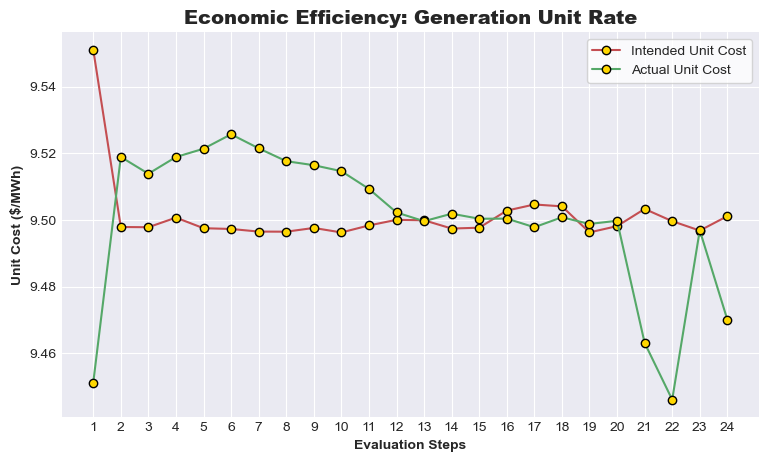

In [28]:
unit_intended = df_results['intended_cost'] / df_results['intended_total_mw']
unit_actual = df_results['actual_cost'] / df_results['actual_total_mw']

plt.figure(figsize=(9, 5))
plt.plot(steps, unit_intended, color='#C44E52', linewidth=1.5,
         marker='o', markerfacecolor='#FFD700', markeredgecolor='black', markersize=6, label='Intended Unit Cost')
plt.plot(steps, unit_actual, color='#55A868', linewidth=1.5,
         marker='o', markerfacecolor='#FFD700', markeredgecolor='black', markersize=6, label='Actual Unit Cost')

plt.title('Economic Efficiency: Generation Unit Rate', fontsize=14, fontweight='black')
plt.xlabel('Evaluation Steps', fontweight='bold')
plt.ylabel('Unit Cost ($/MWh)', fontweight='bold')
plt.xticks(range(1, 25))
plt.legend(loc='best', frameon=True, facecolor='white')
plt.savefig("Figures/greedy_unit_cost.pdf", bbox_inches='tight')
plt.show()

### Comparison of the Agent Performance with the Traditional Optimization Method

In [4]:
# Confirm the setup feasibility with the traditional methods

def diagnostic_check(env):
    Pd = env.P_d_base
    Pg = cp.Variable(env.n_gens)
    
    # Test Power Balance + Gen Limits ONLY
    constraints_simple = [
        cp.sum(Pg) == cp.sum(Pd),
        Pg >= env.P_min,
        Pg <= env.P_max
    ]
    prob_simple = cp.Problem(cp.Minimize(cp.sum(Pg)), constraints_simple)
    prob_simple.solve()
    
    print(f"--- Diagnostic Results ---")
    print(f"Total Load: {np.sum(Pd):.2f} | Total Gen Capacity: {np.sum(env.P_max):.2f}")
    print(f"Balance + Gen Limits Status: {prob_simple.status}")

    # Test with Line Limits
    flows = env.PTDF @ (env.M @ Pg - Pd)
    constraints_full = constraints_simple + [
        flows <= env.F_max,
        flows >= -env.F_max
    ]
    prob_full = cp.Problem(cp.Minimize(cp.sum(Pg)), constraints_full)
    prob_full.solve()
    print(f"Full SCED (with Line Limits) Status: {prob_full.status}")
env = PowerSystemEnv()
diagnostic_check(env)

--- Diagnostic Results ---
Total Load: 5.00 | Total Gen Capacity: 6.00
Balance + Gen Limits Status: optimal
Full SCED (with Line Limits) Status: optimal


C:\Users\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 129302 (\N{ROBOT FACE}) missing from font(s) DejaVu Serif.
  fig.canvas.print_figure(bytes_io, **kw)


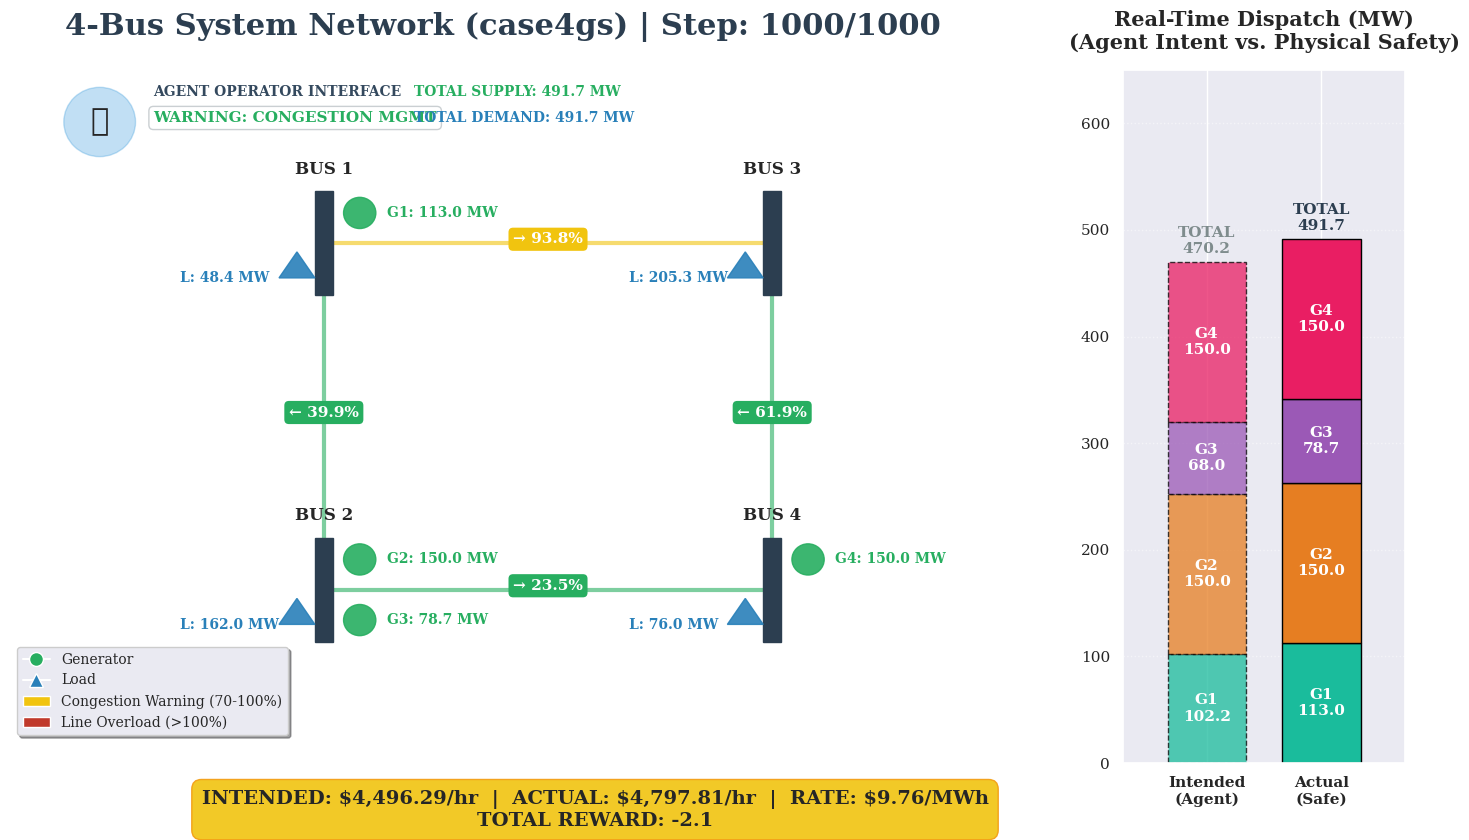

C:\Users\USER!\OneDrive - University at Buffalo\Morufdeen_Atilola_PhD_Journey\Classes\Spring26\CSE546\Assignment\Final Project\PowerSystemEnv.py:556: UserWarning: Glyph 129302 (\N{ROBOT FACE}) missing from font(s) DejaVu Serif.
  fig.savefig(buf, format='png', bbox_inches='tight', dpi=120, facecolor='white')


Completed 1000/1000 steps...
------------------------------
Benchmark Complete!


In [12]:
from td3_model import TD3Agent
from PowerSystemEnv import PowerSystemEnv

env = PowerSystemEnv()
env.max_steps = 1000
agent = TD3Agent(state_dim=12, action_dim=4, max_action=1.0)
agent.load("td3_sced_final_model.pth")

num_tests = 1000
rl_data = []
trad_data = []

print(f"Starting Benchmark for {num_tests} steps...")
print("-" * 30)

env.reset(seed=42)

for i in range(num_tests):

    pd_snapshot = env.current_Pd.copy()
    pg_snapshot = env.current_Pg.copy()

    # --- TRADITIONAL SOLVER (same input) ---
    start_trad = time.perf_counter()
    pg_trad, cost_trad = env.solve_traditional_sced(pd_snapshot)
    trad_time = (time.perf_counter() - start_trad) * 1000

    # --- RL INPUT (same Pd-based observation) ---
    obs_snapshot = env._get_obs()
    start_rl = time.perf_counter()
    action = agent.select_action(obs_snapshot)
    rl_time = (time.perf_counter() - start_rl) * 1000

    # --- NOW evolve system once (separately) ---
    obs, reward, term, trunc, info = env.step(action)

    total_pd_mw = sum(env.current_Pd) * 100 
    Pg_intended = sum(info['Pg_intended']) * 100
    actual_gen_mw = sum(info['Pg_safe']) * 100
    final_residual = actual_gen_mw - total_pd_mw

    if pg_trad is not None:
        trad_data.append({
            'step': i,
            'cost': cost_trad,
            'time': trad_time,
            'pg': pg_trad
        })

        rl_data.append({
            'step': i,
            'total_demand': total_pd_mw,
            'intended_gen': Pg_intended,
            'actual_gen': actual_gen_mw,
            'cost': info['actual_cost'],
            'intended_cost': info['intended_cost'],
            'time': rl_time,
            'pg': info['Pg_safe'],
            'violation': info['violation'],
            'agent_mismatch_mw': info['mismatch'],
            'safe_mismatch_mw': final_residual
        })

    else:
        print(f"Step {i+1}: Traditional Solver failed (Infeasible).")

    # Rendering the last few steps
    if i >= num_tests - 3 and pg_trad is not None:
        
        # --- Traditional ---
        env.current_Pg = np.array(pg_trad)
        env.intended_Pg = np.array(pg_trad)
        env.actual_cost = float(cost_trad)
        env.intended_cost = float(cost_trad)
        env.render(mode="human", episode_reward=0.0)
        
        # Get the last frame added to the env.frames list
        last_frame_trad = Image.fromarray(env.frames[-1])
        last_frame_trad.save(f"Figures/trad_step_{i+1}.png")
        last_frame_trad.convert('RGB').save(f"Figures/trad_step_{i+1}.pdf")

        # --- RL ---
        env.current_Pg = np.array(info['Pg_safe'])
        env.intended_Pg = np.array(info['Pg_intended'])
        env.actual_cost = float(info['actual_cost'])
        env.intended_cost = float(info['intended_cost'])
        env.render(mode="human", episode_reward=float(reward))
        
        # Get the last frame added to the env.frames list
        last_frame_rl = Image.fromarray(env.frames[-1])
        last_frame_rl.save(f"Figures/rl_step_{i+1}.png")
        last_frame_rl.convert('RGB').save(f"Figures/rl_step_{i+1}.pdf")

    if (i + 1) % 100 == 0:
        print(f"Completed {i + 1}/{num_tests} steps...")

print("-" * 30)
print("Benchmark Complete!")

df_rl = pd.DataFrame(rl_data)
df_trad = pd.DataFrame(trad_data)

# Save to csv
df_rl.to_csv("RL_TD3_SCED.csv", index=False)
df_trad.to_csv("Traditional_SCED.csv", index=False)

In [13]:
print(f"--- BENCHMARK COMPLETE ---")
print(f"Avg RL Time: {df_rl['time'].mean():.4f} ms")
print(f"Avg Trad Time: {df_trad['time'].mean():.4f} ms")
print(f"Speedup: {df_trad['time'].mean() / df_rl['time'].mean():.1f}x")
print(f"Avg Cost Gap: {((df_rl['cost'].mean() - df_trad['cost'].mean()) / df_trad['cost'].mean()) * 100:.4f}%")

--- BENCHMARK COMPLETE ---
Avg RL Time: 0.4560 ms
Avg Trad Time: 14.6286 ms
Speedup: 32.1x
Avg Cost Gap: 4.2434%


In [14]:
df_rl.head()

,step,total_demand,intended_gen,actual_gen,cost,intended_cost,time,pg,violation,agent_mismatch_mw,safe_mismatch_mw
0,0,514.940626,477.845073,514.940626,5124.618610,4569.031098,0.9618,"[1.14940626235227, 1.5, 1.0, 1.5]",0.0,37.095553,0.0
1,1,512.737817,487.162977,512.737817,5089.991091,4706.181577,0.3256,"[1.1389482619490856, 1.5, 0.9884299041953319, ...",0.0,25.574839,0.0
2,2,513.286935,487.372357,513.286935,5100.562990,4711.121727,0.3181,"[1.1527700669576788, 1.5, 0.9800992853452826, ...",0.0,25.914579,0.0
3,3,513.030352,492.309344,513.030352,5117.338813,4803.315263,0.3255,"[1.2283504104183947, 1.5, 0.9019531106518542, ...",0.0,20.721008,0.0
4,4,514.045194,485.710114,514.045194,5127.801055,4702.679568,0.5497,"[1.217025328026608, 1.5, 0.9234266165359769, 1.5]",0.0,28.335080,0.0


In [15]:
df_trad.head()

,step,cost,time,pg
0,0,5177.743943,10.9110,"[1.2109311342678222, 1.4824325550249307, 1.0, ..."
1,1,5121.881201,13.7093,"[1.2074057740867017, 1.4710002441327845, 1.0, ..."
2,2,5083.947677,10.1249,"[1.2000630753507509, 1.4636575453968335, 1.0, ..."
3,3,5093.387364,10.5436,"[1.201893470736932, 1.4654879407830148, 1.0, 1..."
4,4,5088.975185,24.8666,"[1.2010381936593615, 1.464632663705444, 1.0, 1..."


### Dispatch Performance (Demand vs Supply)

In [16]:
sns.set_theme(style="darkgrid") 

plt.rcParams.update({
    'font.family': 'serif',
    'font.size': 12,
    'axes.titlesize': 16,
    'axes.titleweight': 'bold',
    'axes.labelweight': 'bold'
})

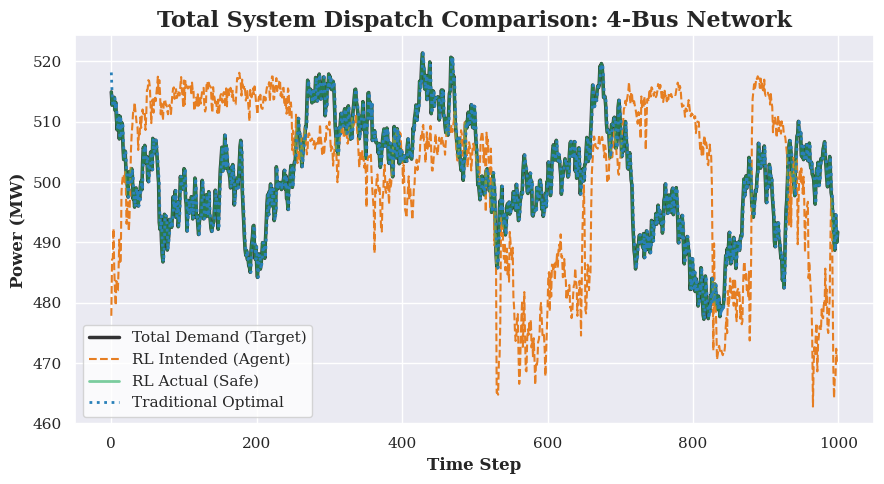

In [17]:
fig, ax = plt.subplots(figsize=(9, 5))

ax.plot(df_rl['step'], df_rl['total_demand'], color='black', linewidth=2.5, label='Total Demand (Target)', alpha=0.8)
ax.plot(df_rl['step'], df_rl['intended_gen'], color='#e67e22', linestyle='--', linewidth=1.5, label='RL Intended (Agent)')
ax.plot(df_rl['step'], df_rl['actual_gen'], color='#27ae60', linewidth=2, label='RL Actual (Safe)', alpha=0.6)
ax.plot(df_trad['step'], df_trad['pg'].apply(lambda x: sum(x)*100), color='#2980b9', linestyle=':', linewidth=2, label='Traditional Optimal')

ax.set_title("Total System Dispatch Comparison: 4-Bus Network")
ax.set_xlabel("Time Step")
ax.set_ylabel("Power (MW)")
ax.legend(frameon=True, facecolor='white')

plt.tight_layout()
plt.savefig("Figures/Dispatch_Comparison.pdf", dpi=300)
plt.savefig("Figures/Dispatch_Comparison.png", dpi=300)
plt.show()

### Economic Efficiency: Cost Comparison

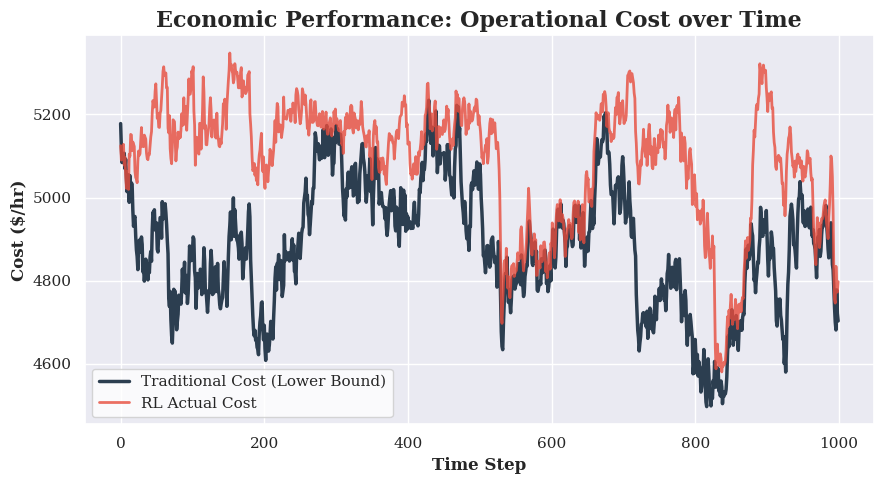

In [18]:
fig, ax = plt.subplots(figsize=(9, 5))

ax.plot(df_trad['step'], df_trad['cost'], color='#2c3e50', linewidth=2.5, label='Traditional Cost (Lower Bound)')
ax.plot(df_rl['step'], df_rl['cost'], color='#e74c3c', linewidth=2, alpha=0.8, label='RL Actual Cost')

ax.set_title("Economic Performance: Operational Cost over Time")
ax.set_xlabel("Time Step")
ax.set_ylabel("Cost ($/hr)")
ax.legend(frameon=True, facecolor='white')

plt.tight_layout()
plt.savefig("Figures/Cost_Comparison.pdf", dpi=300)
plt.savefig("Figures/Cost_Comparison.png", dpi=300)
plt.show()

### Computational Efficiency

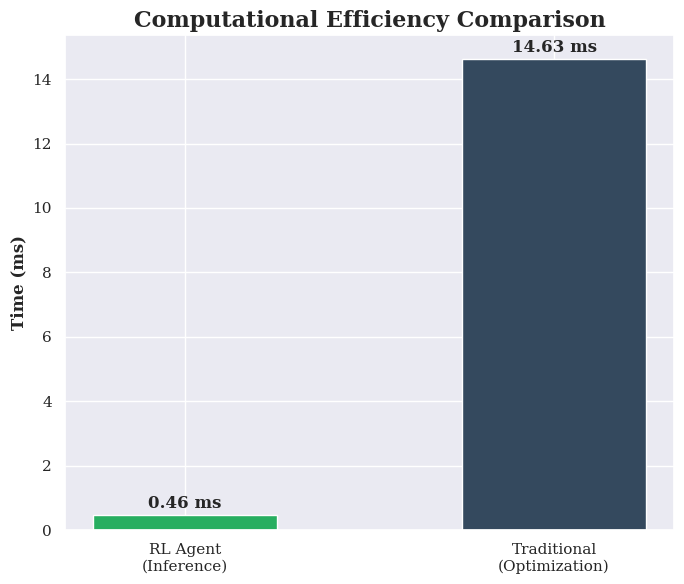

In [19]:
fig, ax = plt.subplots(figsize=(7, 6))

avg_rl = df_rl['time'].mean()
avg_trad = df_trad['time'].mean()

bars = ax.bar(['RL Agent\n(Inference)', 'Traditional\n(Optimization)'], 
              [avg_rl, avg_trad], 
              color=['#27ae60', '#34495e'], width=0.5)

for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 0.1,
            f'{height:.2f} ms', ha='center', va='bottom', fontweight='bold')

ax.set_title("Computational Efficiency Comparison")
ax.set_ylabel("Time (ms)")

plt.tight_layout()
plt.savefig("Figures/Latency_Comparison.pdf", dpi=300)
plt.savefig("Figures/Latency_Comparison.png", dpi=300)
plt.show()

### Stability Analysis

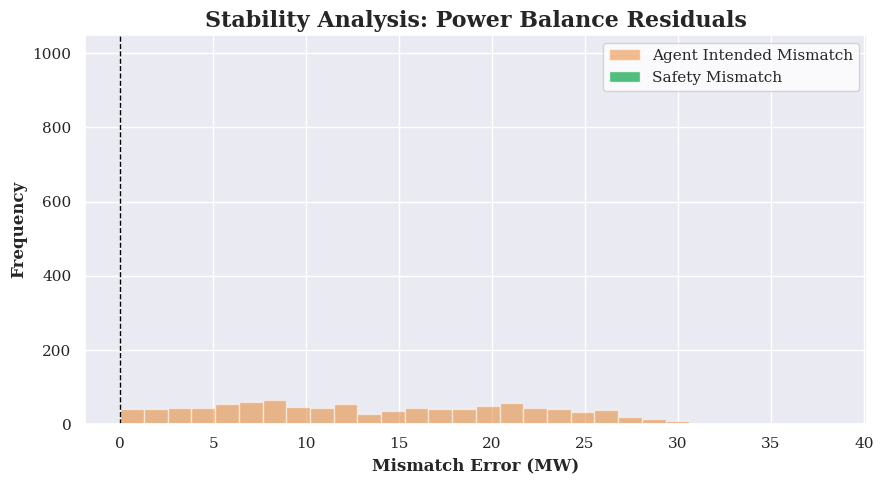

In [20]:
sns.set_theme(style="darkgrid") 
plt.rcParams.update({'font.family': 'serif', 'font.size': 12})

fig, ax = plt.subplots(figsize=(9, 5))

# Agent Mismatch
ax.hist(df_rl['agent_mismatch_mw'], bins=30, color='#e67e22', alpha=0.5, 
        label='Agent Intended Mismatch', edgecolor='white')

# Safe Mismatch
ax.hist(df_rl['safe_mismatch_mw'], bins=10, color='#27ae60', alpha=0.8, 
        label='Safety Mismatch', edgecolor='white')

# Add a vertical line at 0 for reference
ax.axvline(0, color='black', linestyle='--', linewidth=1)

ax.set_title("Stability Analysis: Power Balance Residuals", fontsize=16, fontweight='bold')
ax.set_xlabel("Mismatch Error (MW)", fontweight='bold')
ax.set_ylabel("Frequency", fontweight='bold')
ax.legend(frameon=True, facecolor='white')

plt.tight_layout()
plt.savefig("Figures/Stability_Histogram.pdf", dpi=300)
plt.savefig("Figures/Stability_Histogram.png", dpi=300)
plt.show()

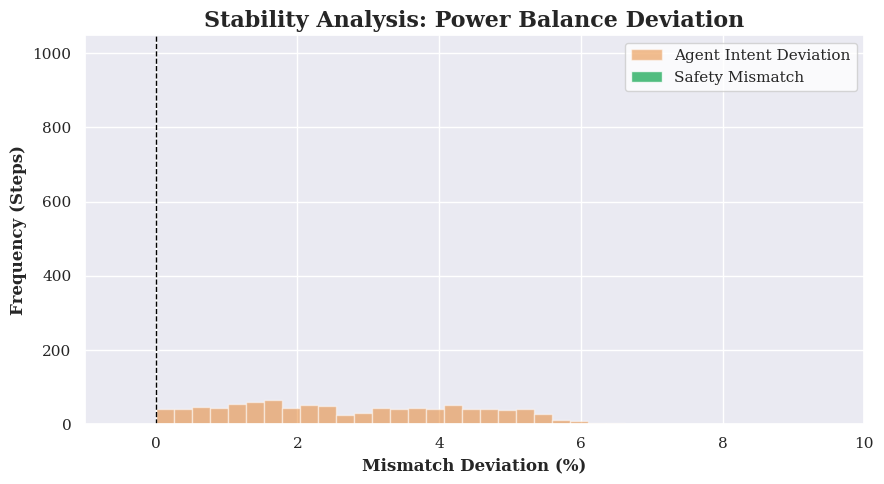

In [21]:
# Calculate Percentage Mismatch
# (Mismatch / Demand) * 100
df_rl['agent_mismatch_pct'] = (df_rl['agent_mismatch_mw'] / df_rl['total_demand']) * 100
df_rl['safe_mismatch_pct'] = (df_rl['safe_mismatch_mw'] / df_rl['total_demand']) * 100

fig, ax = plt.subplots(figsize=(9, 5))

# Plotting the Percentage Distributions
ax.hist(df_rl['agent_mismatch_pct'], bins=30, color='#e67e22', alpha=0.5, 
        label='Agent Intent Deviation', edgecolor='white')
ax.hist(df_rl['safe_mismatch_pct'], bins=10, color='#27ae60', alpha=0.8, 
        label='Safety Mismatch', edgecolor='white')

# Reference line at zero
ax.axvline(0, color='black', linestyle='--', linewidth=1)

ax.set_title("Stability Analysis: Power Balance Deviation", fontsize=16, fontweight='bold')
ax.set_xlabel("Mismatch Deviation (%)", fontweight='bold')
ax.set_ylabel("Frequency (Steps)", fontweight='bold')
ax.legend(frameon=True, facecolor='white')

# Set X-axis limit to focus on the deviation range
ax.set_xlim(-1, 10) 

plt.tight_layout()
plt.savefig("Figures/Stability_Percentage_Histogram.pdf", dpi=300)
plt.savefig("Figures/Stability_Percentage_Histogram.png", dpi=300)
plt.show()